### Step in depth antenna

A step in width microstrip antenna is a design variation where the radiating patch element has a non-uniform width that changes along its length. Instead of a simple rectangular patch, the conducting strip gradually narrows or widens at specific points.

In [15]:
import gmsh
import math
import os
from pathlib import Path

from palacetoolkit.viz import view_mesh
from palacetoolkit.mesh import (
    Entity,
    run_entity_pipeline,
    generate_3d_mesh,
    create_graded_mesh,
    )
from palacetoolkit.simulation import Simulation, run_palace

### Parameters:

- l1 : Ground plane length along x-axis, specified as a scalar in meters
- w1 : Ground plane width along y-axis, specified as a scalar in meters
- h : Patch height along z-axis, specified as a scalar in meters.

- strip_line_length : Notch length along x-axis, specified as a scalar in meters. 
- strip_lined_width_near_port: Notch width along x-axis near the port, specified as a scalar in meters. 
- strip_lined_width_far: Strip line width along y-axis far from the port, specified as a scalar in meters.
- air_height : Air box height along z-axis, specified as a scalar in meters.  
- air_margin : Air box margin along x and y axes, specified as a scalar in meters.
- freq  : Simulation frequency in GHz, specified as a scalar.
- filename : Output mesh filename, specified as a string.

In [16]:
l1: float = 0.06
w1: float = 0.06
strip_line_length: float = 0.06
strip_line_width_near_port: float = 0.001
strip_line_width_far: float = 0.003
h: float = 0.0013
air_height: float = 0.025    
air_margin: float = 0.025    
freq: float = 3.3
filename: str = "sw_antenna.msh"

wavelength = 3e8 / (freq * 1e9)

### Initialize the model

In [17]:
gmsh.initialize()
gmsh.model.add("patch_antenna")
kernel = gmsh.model.occ

### Geometry generation


In [18]:
# Total domain bounds
total_xmin = -l1/2 - air_margin
total_xmax = l1/2 + air_margin
total_ymin = -w1/2 - air_margin
total_ymax = w1/2 + air_margin
total_zmax = h + air_height

substrate = kernel.addBox(-l1/2, -w1/2, 0, l1, w1, h)

ground_plane = kernel.addRectangle(-l1/2, -w1/2, 0, l1, w1)

strip_line_1 = kernel.addRectangle(-l1/2, -strip_line_width_near_port/2, h, strip_line_length/2, strip_line_width_near_port)
strip_line_2 = kernel.addRectangle(0, -strip_line_width_far/2, h, strip_line_length/2, strip_line_width_far)

top_conductor, _ = kernel.fuse(
    [(2, strip_line_1)], [(2, strip_line_2)],
    removeObject=True, removeTool=True
)
kernel.synchronize()

gap = 0
lumped_port = kernel.addRectangle(-l1/2 + gap, -strip_line_width_near_port/2, 0, h - gap, strip_line_width_near_port)
kernel.rotate([(2, lumped_port)], -l1/2, 0, 0, 0, 1, 0, -math.pi/2)
kernel.synchronize()

# Replace box with an enclosing air sphere, following the patch_antenna pattern.
airsphere_radius = max(abs(total_xmin), abs(total_xmax), abs(total_ymin), abs(total_ymax), total_zmax)
air_sphere = kernel.addSphere(0.0, 0.0, 0.0, airsphere_radius)
kernel.synchronize()

Info    : Cannot bind existing OpenCASCADE surface 8 to second tag 9                                                    
Info    : Could not preserve tag of 2D object 9 (->8)


### Entities definition

  Physical group 'air_sphere' (dim=3): pg=1, tags=[2]                                                                                            
  Physical group 'substrate' (dim=3): pg=2, tags=[1]
  Physical group 'top_conductor' (dim=2): pg=3, tags=[8]
  Physical group 'ground_plane' (dim=2): pg=4, tags=[7]
  Physical group 'lumped_port' (dim=2): pg=5, tags=[9]
  Physical group 'air_sphere__None' (dim=2): pg=6, tags=[17]
  Physical group 'air_sphere__substrate' (dim=2): pg=7, tags=[10, 11, 13, 15, 16, 14, 12]
  ppw_near=50  ppw_far=30
  SizeMax=0.0030  transition=0.0227
  global: 8 curves, SizeMin=0.0018
  local (2, 9): 4 curves, SizeMin=0.0006
  Merged 2 fields with Min → field 5
[Entity('air_sphere', dim=3, order=2, tags=[2]), Entity('substrate', dim=3, order=1, tags=[1]), Entity('top_conductor', dim=2, order=1, tags=[8]), Entity('ground_plane', dim=2, order=1, tags=[7]), Entity('lumped_port', dim=2, order=0, tags=[9])]
Loading mesh file: sw_antenna.msh
Groups to render transparen


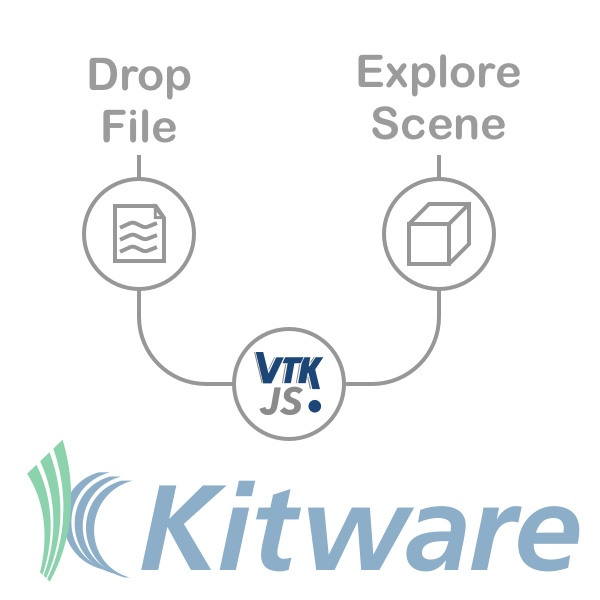

In [ ]:
# Material and port constants reused in meshing/config sections.
eps_r: float = 2.2
loss_tan: float = 0.0009
port_impedance: float = 50.0

entities = [
    Entity("air_sphere", dim=3, btype="dielectric", mesh_order=2, tags=[air_sphere], eps_r=1.0, mu_r=1.0, loss_tan=0.0),
    Entity("substrate", dim=3, btype="dielectric", mesh_order=1, tags=[substrate], eps_r=eps_r, mu_r=1.0, loss_tan=loss_tan),
    Entity("top_conductor", dim=2, btype="pec", mesh_order=1, tags=[top_conductor[0][1]]),
    Entity("ground_plane", dim=2, btype="pec", mesh_order=1, tags=[ground_plane]),
    Entity("lumped_port", dim=2, btype="lumped_port", mesh_order=0, tags=[lumped_port], R=port_impedance, direction="+Z", excitation=True),
]

pg_map = run_entity_pipeline(entities)

# Refine near the top conductor and locally the lumped port
create_graded_mesh(  wavelength, 
                     ppw_near=50, 
                     ppw_far=30, 
                     set_as_background=True,
                     local_refinements={entities[-1].dimtags[0]: 150})

print(entities)

# Mesh sizes
mesh_sizes = {
    "substrate": wavelength / 12,
    "air_sphere": wavelength / 4,
    "lumped_port": wavelength / 150,
    "ground_plane": wavelength / 10,
    "top_conductor": wavelength / 50,
}

generate_3d_mesh(entities, mesh_sizes, filename, optimize=True, verbose=False)

view_mesh(filename, transparent_groups="air_sphere__None")

### Generate JSON config


In [20]:
output_file: str = "sw_antenna.json"
freq_min: float = 3.0
freq_max: float = 3.5
freq_step: float = 0.005
solver_order: int = 2

In [21]:
def attr(name):
        return [pg_map[name]] if name in pg_map else []

sim = Simulation(output_dir=os.getcwd(), apply_mesh_options=False)
sim.config = {
    "Problem": {
        "Type": "Driven",
        "Verbose": 2,
        "Output": "postpro/sw_antenna"
    },

    "Model": {
        "Mesh": filename,
        "L0": 1.0,
        "Refinement": {}
    },

    "Domains": {
        "Materials": [
            {
                "Attributes": attr("substrate"),
                "Permittivity": eps_r,
                "Permeability": 1.0,
                "LossTan": loss_tan
            },
            {
                "Attributes": attr("air"),
                "Permittivity": 1.0,
                "Permeability": 1.0
            }
        ]
    },

    "Boundaries": {
        "PEC": {
            "Attributes": attr("ground_plane") + attr("patch")
        },

        "LumpedPort": [
            {
                "Index": 1,
                "Attributes": attr("lumped_port"),
                "R": port_impedance,
                "Excitation": True,
                "Direction": "+Z"
            }
        ],

        "Absorbing": {
            "Attributes": attr("farfield"),
            "Order": 1
        }
    },

    "Solver": {
        "Order": solver_order,
        "Device": "CPU",

        "Driven": {
            "MinFreq": freq_min,
            "MaxFreq": freq_max,
            "FreqStep": freq_step,
            "AdaptiveTol": 0.001
        },

        "Linear": {
            "Type": "Default",
            "KSPType": "GMRES",
            "Tol": 1.0e-8,
            "MaxIts": 200,
            "ComplexCoarseSolve": True
        }
    }
}

config_path = str(sim.write_config(output_file))
run_palace(config_path, num_procs=8, work_dir=os.getcwd())

Palace config written to /home/martin/Desktop/PalaceToolkit/docs/examples/sw_antenna.json
  Running: apptainer exec --pwd /work --bind /home/martin/Desktop/PalaceToolkit/docs/examples:/work /opt/palace/Palace.sif mpirun -np 8 /opt/palace/bin/palace-x86_64.bin /work/sw_antenna.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (postpro/sw_antenna)
Git changeset ID: v0.14.0-270-g9d6ea72f
Running with 8 MPI processes, 1 OpenMP thread
Device configuration: omp,cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Removed 126398 unmarked domain elements from the mesh
Removed 11012 unattached boundary elements from the mesh

--> Warning!
One or more external boundary attributes has no associated boundary condition!
"PMC"/"ZeroCharge" condition